In [1]:
from datascience import *
import numpy as np
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
plots.rcParams["patch.force_edgecolor"] = True

In [2]:
# Data from https://www.boxofficemojo.com/chart/ww_top_lifetime_gross/
top_movies = Table.read_table('top_movies_2026.csv')
top_movies.show(4)

Title,Worldwide Lifetime Gross,Domestic Lifetime Gross,Foreign Lifetime Gross,Year
Avatar,2923710708,785221649,2138489059,2009
Avengers: Endgame,2799439100,858373000,1941066100,2019
Avatar: The Way of Water,2334484620,688459501,1646025119,2022
Titanic,2264812968,674354882,1590458086,1997


In [3]:
top_movies.set_format([1, 2, 3], CurrencyFormatter).show(4)

Title,Worldwide Lifetime Gross,Domestic Lifetime Gross,Foreign Lifetime Gross,Year
Avatar,"$2,923,710,708","$785,221,649","$2,138,489,059",2009
Avengers: Endgame,"$2,799,439,100","$858,373,000","$1,941,066,100",2019
Avatar: The Way of Water,"$2,334,484,620","$688,459,501","$1,646,025,119",2022
Titanic,"$2,264,812,968","$674,354,882","$1,590,458,086",1997


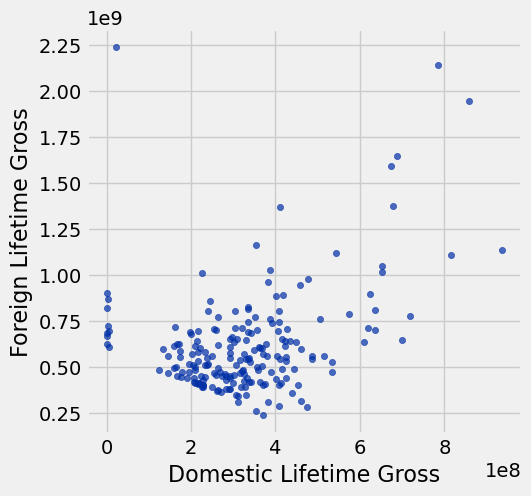

In [4]:
top_movies.scatter(2, 3)

In [5]:
top_movies.sort(3, descending=True).show(5)

Title,Worldwide Lifetime Gross,Domestic Lifetime Gross,Foreign Lifetime Gross,Year
Ne Zha 2,"$2,259,822,417","$23,308,176","$2,236,514,241",2025
Avatar,"$2,923,710,708","$785,221,649","$2,138,489,059",2009
Avengers: Endgame,"$2,799,439,100","$858,373,000","$1,941,066,100",2019
Avatar: The Way of Water,"$2,334,484,620","$688,459,501","$1,646,025,119",2022
Titanic,"$2,264,812,968","$674,354,882","$1,590,458,086",1997


### Use binning for numerical distributions

#### **Task**: Visualize the distribution of movie ages

In [6]:
ages = 2026 - top_movies.column('Year')
ages

array([17,  7,  4, 29,  1, 11,  8,  5,  1,  2, 11,  7, 14, 11,  4,  7,  3,
        1, 11,  3,  8, 15,  2,  9,  8, 13,  9,  8,  9, 13, 11, 10,  8, 23,
        7,  7, 15, 14, 12, 33, 14,  7,  7,  7, 16, 20,  2, 10,  7, 15, 27,
        1,  9, 25, 10, 10, 16, 14, 18,  4, 32,  3,  2, 13, 10, 12,  9, 19,
       16, 13,  1,  4, 24, 19, 23, 17,  4, 22,  8, 21,  5, 21, 25, 19, 17,
       24,  9, 11, 14, 10, 10,  9,  1, 14, 13,  9,  4, 11,  8,  9,  3, 16,
       17,  8,  9,  9,  5, 30, 10, 24, 22, 19,  7, 20, 44,  9, 17, 13, 18,
        8, 22, 10, 49,  5, 12, 12,  4,  4,  7, 16, 12, 12,  2, 14, 16, 10,
       14, 12, 21, 13, 23, 17, 15,  1,  5,  7, 13,  2,  9, 12,  2, 12, 17,
       11, 12, 19,  3,  7, 14, 15,  3,  5, 32, 10, 27, 12,  3, 13, 20, 15,
       11,  9,  8, 23, 14, 24, 13, 10,  1,  3, 10, 18,  1, 22, 11, 18,  4,
       15, 16, 19,  8, 12,  9, 29,  1, 20,  3, 18, 22, 14])

In [7]:
top_movies = top_movies.with_column('Age', ages)
top_movies

Title,Worldwide Lifetime Gross,Domestic Lifetime Gross,Foreign Lifetime Gross,Year,Age
Avatar,"$2,923,710,708","$785,221,649","$2,138,489,059",2009,17
Avengers: Endgame,"$2,799,439,100","$858,373,000","$1,941,066,100",2019,7
Avatar: The Way of Water,"$2,334,484,620","$688,459,501","$1,646,025,119",2022,4
Titanic,"$2,264,812,968","$674,354,882","$1,590,458,086",1997,29
Ne Zha 2,"$2,259,822,417","$23,308,176","$2,236,514,241",2025,1
Star Wars: Episode VII - The Force Awakens,"$2,071,310,218","$936,662,225","$1,134,647,993",2015,11
Avengers: Infinity War,"$2,052,415,039","$678,815,482","$1,373,599,557",2018,8
Spider-Man: No Way Home,"$1,921,426,073","$814,866,759","$1,106,559,314",2021,5
Zootopia 2,"$1,778,775,365","$410,218,402","$1,368,556,963",2025,1
Inside Out 2,"$1,698,863,816","$652,980,194","$1,045,883,622",2024,2


In [8]:
top_movies.select('Title', 'Age').show(6)

Title,Age
Avatar,17
Avengers: Endgame,7
Avatar: The Way of Water,4
Titanic,29
Ne Zha 2,1
Star Wars: Episode VII - The Force Awakens,11


In [9]:
min(ages), max(ages)

(1, 49)

- If you want to make equally sized bins, `np.arange()` is a great tool to help you.

In [29]:
np.arange(0, max(ages)+10, 10)

array([ 0, 10, 20, 30, 40, 50])

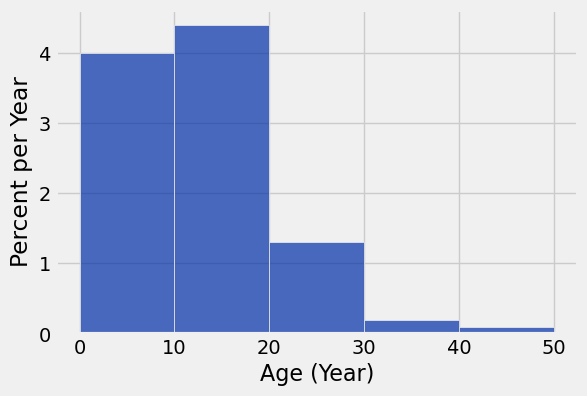

In [31]:
top_movies.hist('Age', bins = np.arange(0, max(ages)+10, 10), unit = 'Year')

- Otherwise, you can pick your own bins. These are just bins that we picked out.


In [41]:
my_bins = make_array(0, 5, 10, 15, 25, 60)

In [42]:
binned_data = top_movies.bin('Age', bins = my_bins)
binned_data

bin,Age count
0,35
5,45
10,56
15,52
25,12
60,0


**Note:** The last "bin" does not include any observations!!

### Introducing the histogram and the area principle

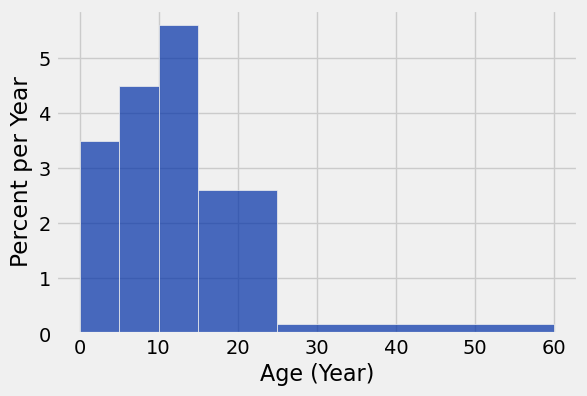

In [43]:
top_movies.hist('Age', bins = my_bins, unit = 'Year')

#### **Discussion Question**: Compare the bins $[0, 5)$ and $[15, 25)$. 

- Which one has more movies?
- Which one is more crowded?

### Challenge tasks

#### **Task**: Find the height of the $[15,25)$ bin in the histogram above.

$$\text{height} = \frac{\text{percent}}{\text{width}}$$

Add a column containing what percent of movies are in each bin (the **area** of each bin)

In [44]:
binned_data = binned_data.with_column('Percent', 100*binned_data.column('Age count')/top_movies.num_rows)

In [45]:
binned_data.show()

bin,Age count,Percent
0,35,17.5
5,45,22.5
10,56,28
15,52,26
25,12,6
60,0,0


In [46]:
percent = binned_data.where('bin', 15).column('Percent').item(0)

In [47]:
width = 25-15
height = percent / width

In [48]:
height

2.6

#### **Task**: Find the heights of the (rest of the) bins.

$$\text{height} = \frac{\text{percent}}{\text{width}}$$

Remember that the last row in the table does not represent a bin!

In [49]:
height_table = binned_data.take(np.arange(binned_data.num_rows - 1))
height_table 

bin,Age count,Percent
0,35,17.5
5,45,22.5
10,56,28
15,52,26
25,12,6


Remember `np.diff`?

In [50]:
bin_widths = np.diff(binned_data.column('bin'))

In [51]:
bin_widths

array([ 5,  5,  5, 10, 35])

In [52]:
height_table = height_table.with_column('Width', bin_widths)
height_table

bin,Age count,Percent,Width
0,35,17.5,5
5,45,22.5,5
10,56,28,5
15,52,26,10
25,12,6,35


In [53]:
height_table = height_table.with_column('Height',
                                        height_table.column('Percent')/height_table.column('Width'))

In [54]:
height_table

bin,Age count,Percent,Width,Height
0,35,17.5,5,3.5
5,45,22.5,5,4.5
10,56,28,5,5.6
15,52,26,10,2.6
25,12,6,35,0.171429


To check our work one last time, let's see if the numbers in the last column match the heights of the histogram:

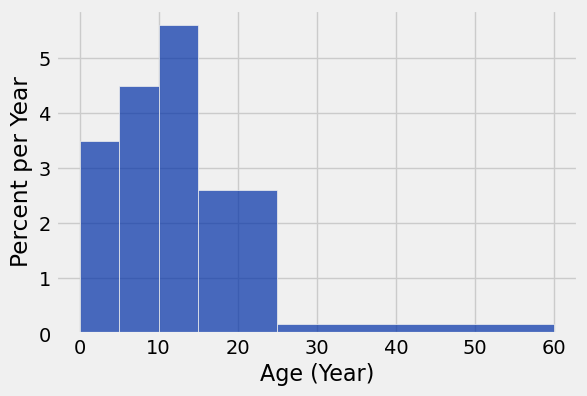

In [55]:
top_movies.hist('Age', bins = my_bins, unit = 'Year')